In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from torch.utils.data import DataLoader
from dataset2 import YOLODataset, collect_fn
import config
from torch import tensor, arange, float as tfloat, stack
import matplotlib.pyplot as plt
import matplotlib.patches as pat

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRot

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [ ]:
import MyRCNN
import torch
device = config.DEVICE
model = MyRCNN.Model(bbx_epoches=1, cls_epoches=0)
model = model.to(device)
model.train()

[00:23:43] Epoch 0/1; Loss 1.8085875511169434 █                                                      82       /     4138

In [4]:
# model.Evaluate()

torch.Size([1, 32, 312, 312])
-3251.4595 -3247.2102
0.010803223 0.01083374
0.048706055 0.04862976
-13.767548 -13.748688
-480.39392 -481.48508
-6.1035156e-05 -6.1035156e-05
0.03543091 0.035110474
789.6288 787.3181
0.048736572 0.04876709
0.0 0.0
-0.00030517578 -0.00030517578
-133.02307 -133.5904
-14.8359375 -14.74173
-3409.2305 -3412.649
183002.84 183195.78
164905.48 164803.19
0.0513916 0.051483154
270808.72 270839.88
-2421.0962 -2419.8027
2206.4976 2202.1953
139400.31 139468.27
-1080.2329 -1080.5248
-2610.2578 -2611.2173
-0.00024414062 -0.00024414062
0.06588745 0.065704346
0.04385376 0.043762207
0.013977051 0.013946533
-3.0517578e-05 -3.0517578e-05
0.016418457 0.016418457
-410.5995 -410.84253
-0.0012207031 -0.0012207031
398928.62 398600.84


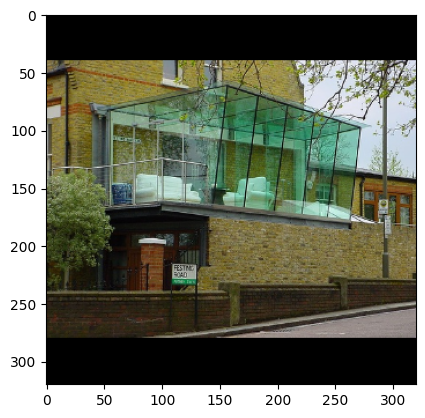

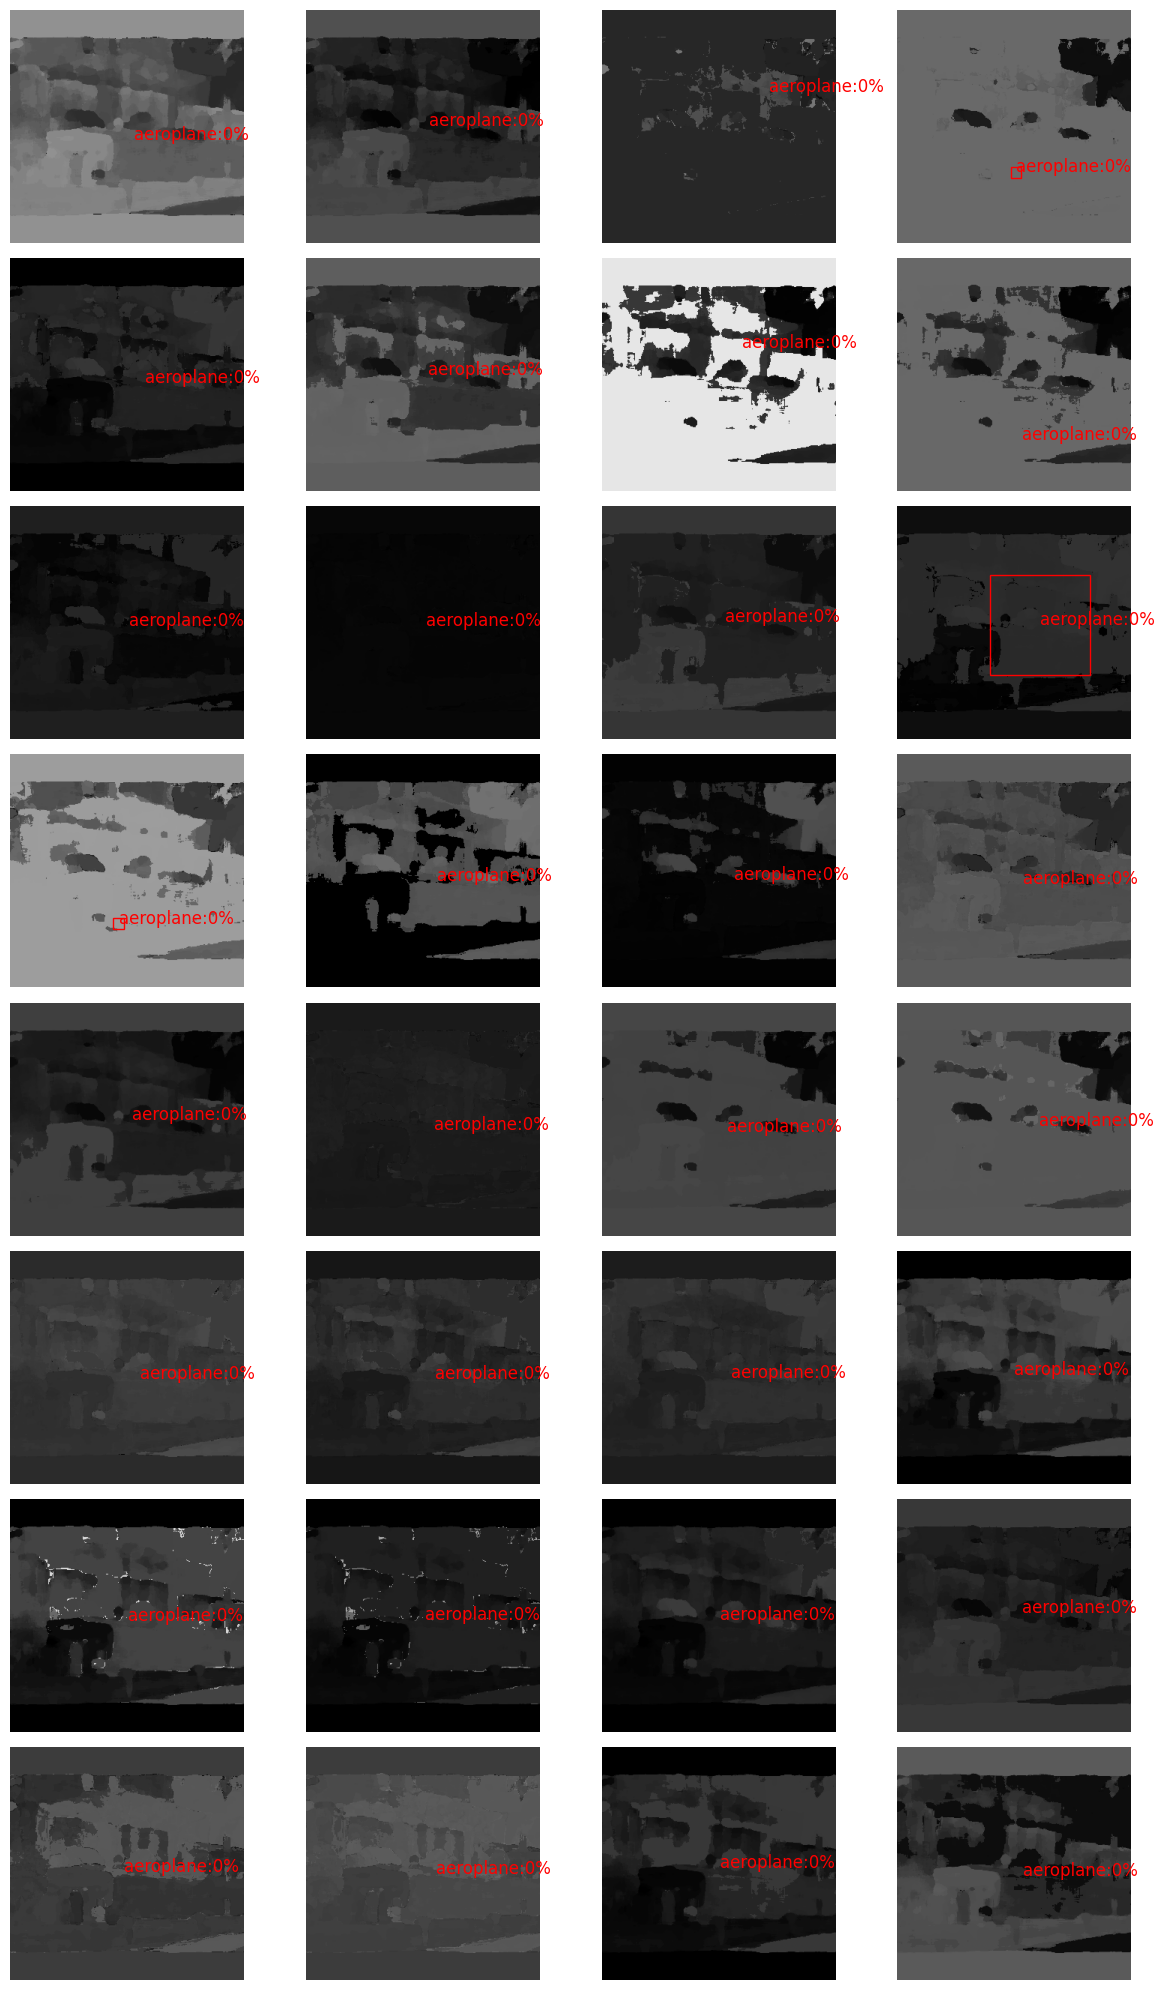

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torch import sigmoid, softmax, zeros, bool as tbool
from dataset import TensorToImg, ImgToTensor

model.eval()
for i, (tens,label) in enumerate(model.loader):
    if (i==0): continue
    data = tens.to(device)
    boundary, score, bbx = model.model(data)
    color = model.model.color(data)
    prep = model.model.color.prepare(data)
    print(prep.shape)
    # x =score
    # x = color[:, 1:2,: ,:]
    # x = x.repeat(1, 3, 1, 1)
    # x = x-x.min()
    # x = x/x.max()
    x = tens
    x = TensorToImg(x.detach().cpu())
    plt.imshow(x)
    N = prep.shape[1]
    fig, axes = plt.subplots(N//4, 4, figsize=(12, 20))
    cls_range = arange(20).view(20, 1, 1).expand(20, N, 1)
    for i, ax in enumerate(axes.flat):
        x = prep[:, i:i+1, :, :]
        # print(x.min(), x.max())
        x = x.repeat(1, 3, 1, 1)
        x = x-x.min()
        # x = x/x.max()
        cls, x1, y1, x2, y2, sc = bbx[i].detach().cpu().numpy()
        print((x2 -x1), (y2-y1))
        rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
        ax.add_patch(rect)
        ax.text((x1+x2)/2, (y1+y2)/2, f"{config.PASCAL_CLASSES[cls.astype(int)]}:{0}%", fontsize=12, color='red')
        ax.imshow(TensorToImg(x.detach().cpu()))
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break